# Power Spectral Density (PSD) in Python

This notebook explores **Spectral Density estimation** from first principles. We will cover:

- What is PSD and its physical meaning
- The Periodogram (direct method)
- Welch's method: averaging for variance reduction
- Effect of window choice on PSD estimates
- PSD of colored noise: white, pink, and Brownian
- Parseval's theorem: energy conservation between time and frequency
- Cross Spectral Density (CSD) and Magnitude-Squared Coherence
- PSD of modulated (AM) signals
- Linear vs dB scaling for dynamic range

**Requirements:** `numpy`, `matplotlib`, `scipy`


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram, welch, csd, coherence
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10


## 1. What is Power Spectral Density?

The **Power Spectral Density** $S_{xx}(f)$ describes how the power of a signal is distributed across frequencies. For a continuous signal $x(t)$:

$$S_{xx}(f) = \lim_{T \to \infty} \frac{1}{T} \left| \int_{-T/2}^{T/2} x(t) e^{-j 2\pi f t} dt \right|^2$$

In practice, we estimate PSD from finite discrete samples. The units are **power per unit frequency** (e.g., V$^2$/Hz if the signal is in volts).

Key properties:
- The integral of PSD over all frequencies equals the total signal power: $\int_{-\infty}^{\infty} S_{xx}(f) df = \text{mean}(x^2)$
- PSD is always real and non-negative
- For real signals, the one-sided PSD (0 to $f_s/2$) is used, with non-DC components doubled

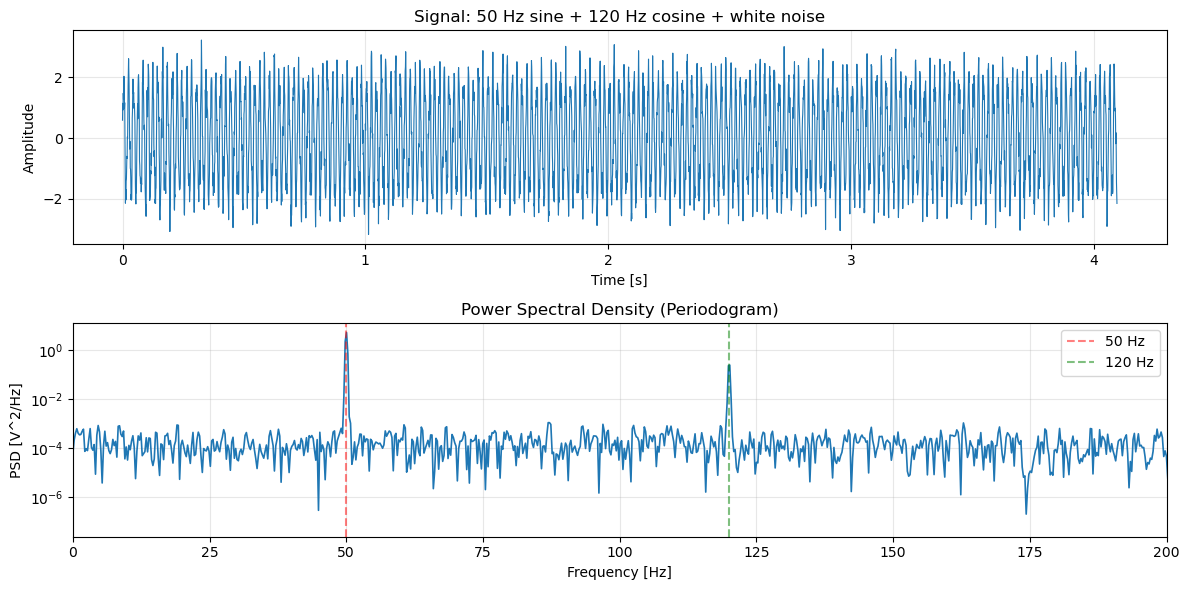

In [16]:
# Generate a test signal with known frequency content
fs = 1000
N = 4096
t = np.arange(N) / fs
f1, f2 = 50, 120
signal = (2.0 * np.sin(2 * np.pi * f1 * t) + 
          0.5 * np.cos(2 * np.pi * f2 * t) + 
          0.3 * np.random.randn(N))

# Periodogram: direct squared-magnitude of FFT, properly scaled
f_per, psd_per = periodogram(signal, fs=fs, window='hann', nfft=N)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t, signal, linewidth=0.8)
axes[0].set_title('Signal: 50 Hz sine + 120 Hz cosine + white noise')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(f_per, psd_per, linewidth=1.2)
axes[1].axvline(f1, color='r', linestyle='--', alpha=0.5, label='{} Hz'.format(f1))
axes[1].axvline(f2, color='g', linestyle='--', alpha=0.5, label='{} Hz'.format(f2))
axes[1].set_title('Power Spectral Density (Periodogram)')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('PSD [V^2/Hz]')
axes[1].set_xlim(0, 200)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Periodogram Limitations and Welch's Method

The raw periodogram is a **biased and inconsistent estimator**: its variance does not decrease as we add more data. The estimate fluctuates wildly between realizations.

**Welch's method** improves this by:
1. Dividing the signal into overlapping segments (typically 50% overlap)
2. Windowing each segment to reduce spectral leakage
3. Computing the periodogram for each segment
4. Averaging the periodograms

This trades frequency resolution for **lower variance**. The variance decreases proportionally to the number of averaged segments.


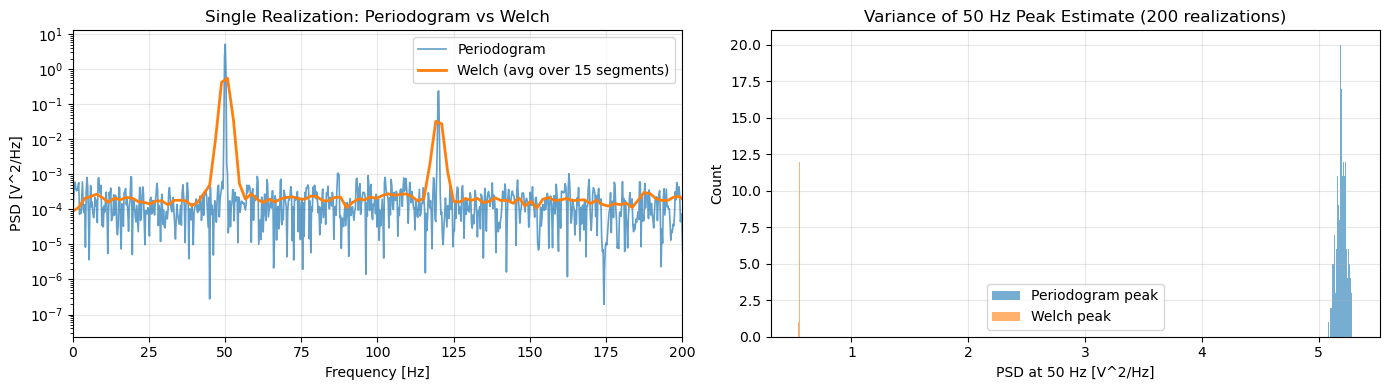

Periodogram peak std: 0.0420
Welch peak std:     0.0038


In [17]:
# Compare periodogram vs Welch
f_welch, psd_welch = welch(signal, fs=fs, window='hann', nperseg=512, noverlap=256)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(f_per, psd_per, alpha=0.7, label='Periodogram', linewidth=1.2)
axes[0].semilogy(f_welch, psd_welch, linewidth=2, label='Welch (avg over 15 segments)')
axes[0].set_title('Single Realization: Periodogram vs Welch')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('PSD [V^2/Hz]')
axes[0].set_xlim(0, 200)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Variance comparison across many realizations
n_realizations = 200
periodogram_peaks = np.zeros(n_realizations)
welch_peaks = np.zeros(n_realizations)

for i in range(n_realizations):
    noise = 0.3 * np.random.randn(N)
    sig = 2.0 * np.sin(2 * np.pi * f1 * t) + noise
    f_p, p_p = periodogram(sig, fs=fs, window='hann', nfft=N)
    f_w, p_w = welch(sig, fs=fs, window='hann', nperseg=512, noverlap=256)
    # Measure peak in band around 50 Hz
    mask_p = (f_p > 45) & (f_p < 55)
    mask_w = (f_w > 45) & (f_w < 55)
    periodogram_peaks[i] = np.max(p_p[mask_p])
    welch_peaks[i] = np.max(p_w[mask_w])

axes[1].hist(periodogram_peaks, bins=30, alpha=0.6, label='Periodogram peak')
axes[1].hist(welch_peaks, bins=30, alpha=0.6, label='Welch peak')
axes[1].set_title('Variance of 50 Hz Peak Estimate (200 realizations)')
axes[1].set_xlabel('PSD at 50 Hz [V^2/Hz]')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Periodogram peak std: {:.4f}".format(np.std(periodogram_peaks)))
print("Welch peak std:     {:.4f}".format(np.std(welch_peaks)))


## 3. Effect of Window Choice on PSD

The window function shapes the trade-off between:
- **Spectral leakage** (side lobes): energy from a strong tone bleeding into other frequencies
- **Frequency resolution** (main lobe width): ability to separate two close frequencies

A rectangular window has the narrowest main lobe but terrible side lobes. A Blackman window has very low side lobes but smears nearby frequencies together.

When the signal frequency does not fall exactly on a frequency bin (off-bin), leakage becomes visible.


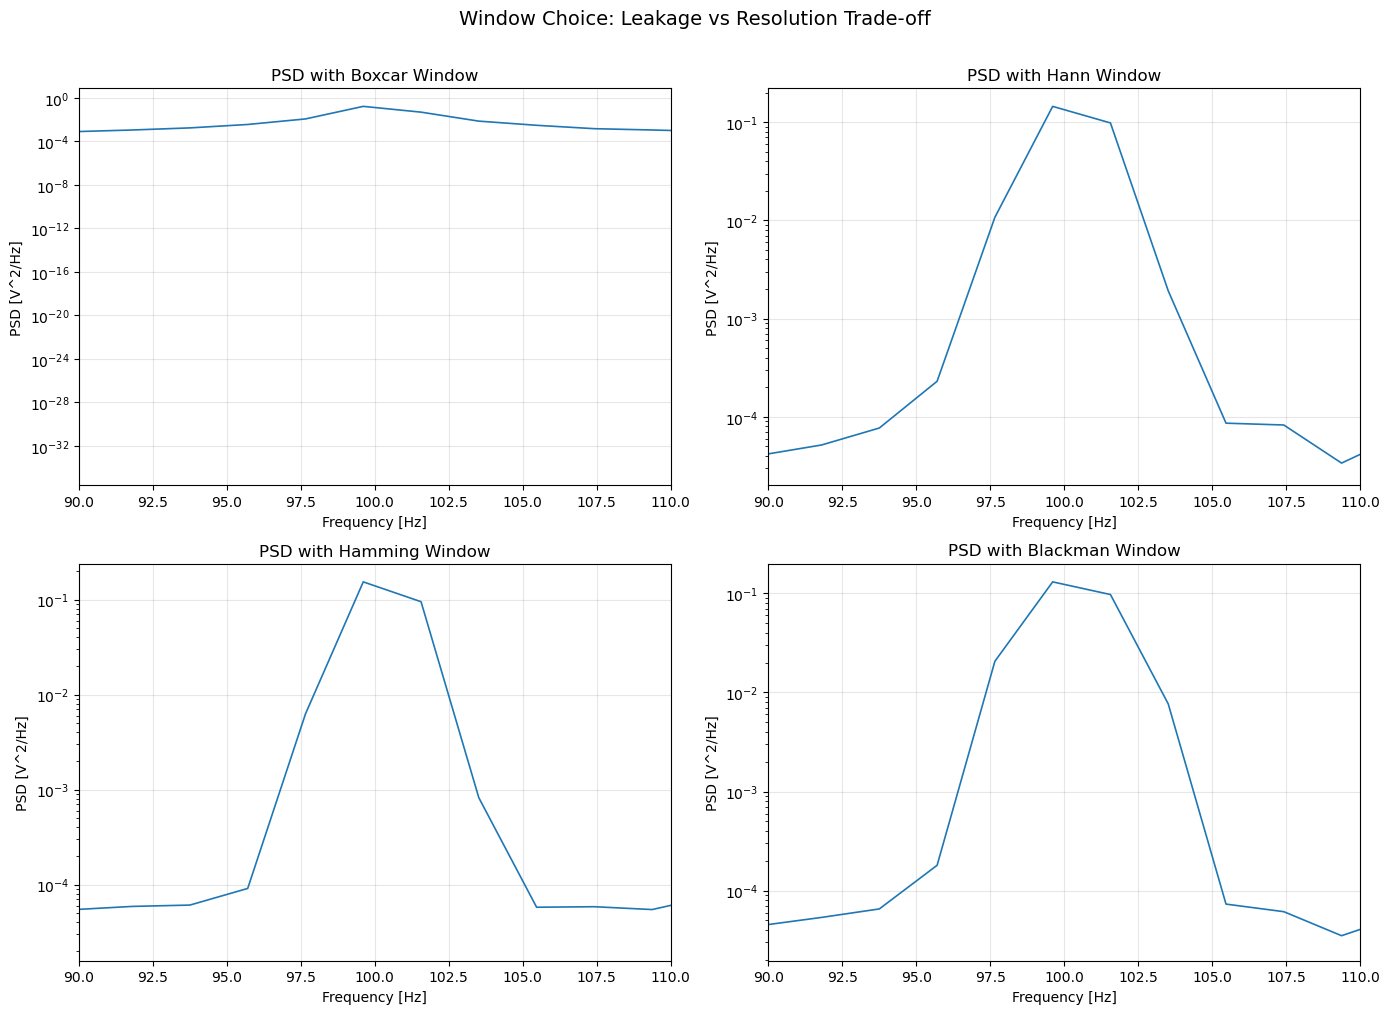

In [18]:
fs = 1000
N = 4096
t = np.arange(N) / fs
f_sig = 100.3  # Off-bin frequency to induce leakage
sig = np.sin(2 * np.pi * f_sig * t) + 0.2 * np.random.randn(N)

window_list = ['boxcar', 'hann', 'hamming', 'blackman']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, win in enumerate(window_list):
    ax = axes[idx // 2, idx % 2]
    f_w, psd_w = welch(sig, fs=fs, window=win, nperseg=512, noverlap=256)
    ax.semilogy(f_w, psd_w, linewidth=1.2)
    ax.set_title('PSD with {} Window'.format(win.capitalize()))
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('PSD [V^2/Hz]')
    ax.set_xlim(90, 110)
    ax.grid(True, alpha=0.3)

plt.suptitle('Window Choice: Leakage vs Resolution Trade-off', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 4. Colored Noise: White, Pink, and Brownian

Not all noise has flat spectral density. The color of noise describes its PSD slope:

| Type | PSD Slope | Characteristics |
|------|-----------|-----------------|
| **White** | $S(f) \propto f^0$ (flat) | Uncorrelated samples |
| **Pink** | $S(f) \propto 1/f$ | Common in nature, equal power per octave |
| **Brown** | $S(f) \propto 1/f^2$ | Integrated white noise, strong low-frequency content |

We generate colored noise by shaping white noise in the frequency domain.


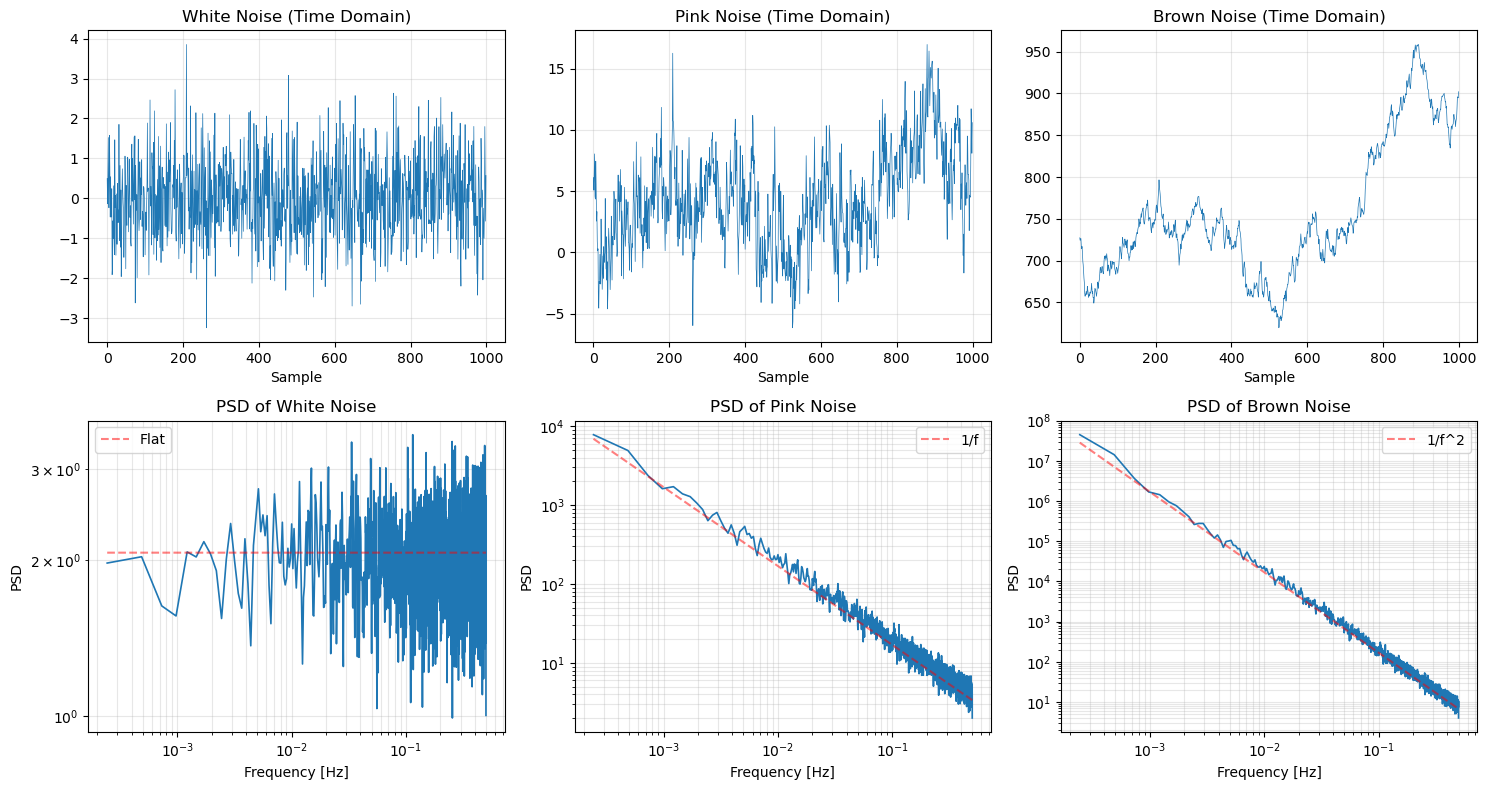

In [19]:
def colored_noise(N, color='white'):
    """Generate colored noise via FFT-based spectral shaping."""
    white = np.fft.rfft(np.random.randn(N))
    freqs = np.fft.rfftfreq(N)
    freqs[0] = 1.0  # Avoid division by zero at DC
    if color == 'pink':
        white = white / np.sqrt(freqs)
    elif color == 'brown':
        white = white / freqs
    elif color == 'blue':
        white = white * np.sqrt(freqs)
    elif color == 'violet':
        white = white * freqs
    return np.fft.irfft(white, n=N)

N_noise = 2**16
fs_n = 1.0
colors = ['white', 'pink', 'brown']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(colors):
    np.random.seed(42)
    noise = colored_noise(N_noise, col)
    f_n, psd_n = welch(noise, fs=fs_n, nperseg=4096)
    
    # Time domain (first 1000 samples)
    axes[0, idx].plot(noise[:1000], linewidth=0.5)
    axes[0, idx].set_title('{} Noise (Time Domain)'.format(col.capitalize()))
    axes[0, idx].set_xlabel('Sample')
    axes[0, idx].grid(True, alpha=0.3)
    
    # PSD on log-log axes
    axes[1, idx].loglog(f_n[1:], psd_n[1:], linewidth=1.2)  # Skip DC
    if col == 'white':
        ref = np.mean(psd_n[10:100]) * np.ones_like(f_n[1:])
        axes[1, idx].loglog(f_n[1:], ref, 'r--', alpha=0.5, label='Flat')
    elif col == 'pink':
        ref = psd_n[50] * (f_n[50] / f_n[1:])
        axes[1, idx].loglog(f_n[1:], ref, 'r--', alpha=0.5, label='1/f')
    elif col == 'brown':
        ref = psd_n[50] * (f_n[50] / f_n[1:])**2
        axes[1, idx].loglog(f_n[1:], ref, 'r--', alpha=0.5, label='1/f^2')
    axes[1, idx].set_title('PSD of {} Noise'.format(col.capitalize()))
    axes[1, idx].set_xlabel('Frequency [Hz]')
    axes[1, idx].set_ylabel('PSD')
    axes[1, idx].grid(True, alpha=0.3, which='both')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()


## 5. Parseval's Theorem: Energy Conservation

Parseval's theorem states that the total energy (or power) in the time domain equals the total energy in the frequency domain:

$$\text{mean}(x^2[n]) = \int_{0}^{f_s/2} S_{xx}(f) \, df$$

For a properly scaled PSD, the area under the curve equals the mean squared amplitude of the signal. We verify this numerically using rectangular integration (summing PSD values times the frequency step).


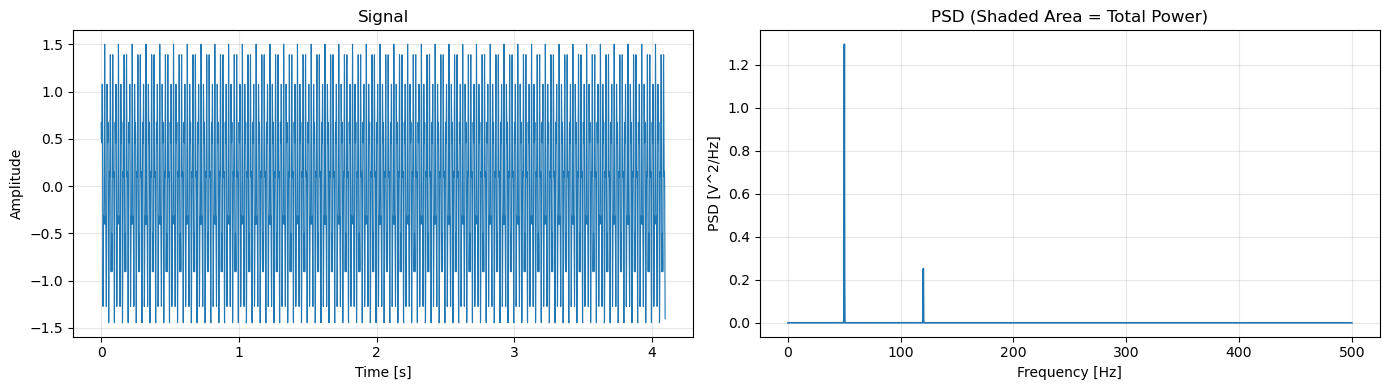

Time domain mean power:     0.624712
Freq domain (Periodogram):  0.625001
Freq domain (Welch):        0.625078
Parseval residual (Periodogram): 2.88e-04
Parseval residual (Welch):       3.65e-04


In [20]:
fs = 1000
N = 4096
t = np.arange(N) / fs
x = np.sin(2 * np.pi * 50 * t) + 0.5 * np.cos(2 * np.pi * 120 * t)

# Time domain power
time_power = np.mean(x**2)

# Frequency domain power via periodogram
f_p, psd_p = periodogram(x, fs=fs, window='hann')
df = f_p[1] - f_p[0]
freq_power = np.sum(psd_p) * df  # Rectangular integration

# Also via Welch
f_w, psd_w = welch(x, fs=fs, window='hann', nperseg=512, noverlap=256)
df_w = f_w[1] - f_w[0]
freq_power_welch = np.sum(psd_w) * df_w

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t, x, linewidth=0.8)
axes[0].set_title('Signal')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(f_p, psd_p, alpha=0.3)
axes[1].plot(f_p, psd_p, linewidth=1.2)
axes[1].set_title('PSD (Shaded Area = Total Power)')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('PSD [V^2/Hz]')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Time domain mean power:     {:.6f}".format(time_power))
print("Freq domain (Periodogram):  {:.6f}".format(freq_power))
print("Freq domain (Welch):        {:.6f}".format(freq_power_welch))
print("Parseval residual (Periodogram): {:.2e}".format(abs(time_power - freq_power)))
print("Parseval residual (Welch):       {:.2e}".format(abs(time_power - freq_power_welch)))


## 6. Cross Spectral Density (CSD) and Coherence

The **Cross Spectral Density** $S_{xy}(f)$ measures the spectral correlation between two signals. It is complex-valued, with magnitude indicating shared spectral power and phase indicating the time delay relationship.

**Magnitude-Squared Coherence** normalizes this to a value between 0 and 1:

$$C_{xy}(f) = \frac{|S_{xy}(f)|^2}{S_{xx}(f) \cdot S_{yy}(f)}$$

- $C_{xy} = 1$: perfect linear relationship at that frequency
- $C_{xy} = 0$: no linear relationship

This is essential for identifying shared frequency components in noisy multi-sensor recordings.


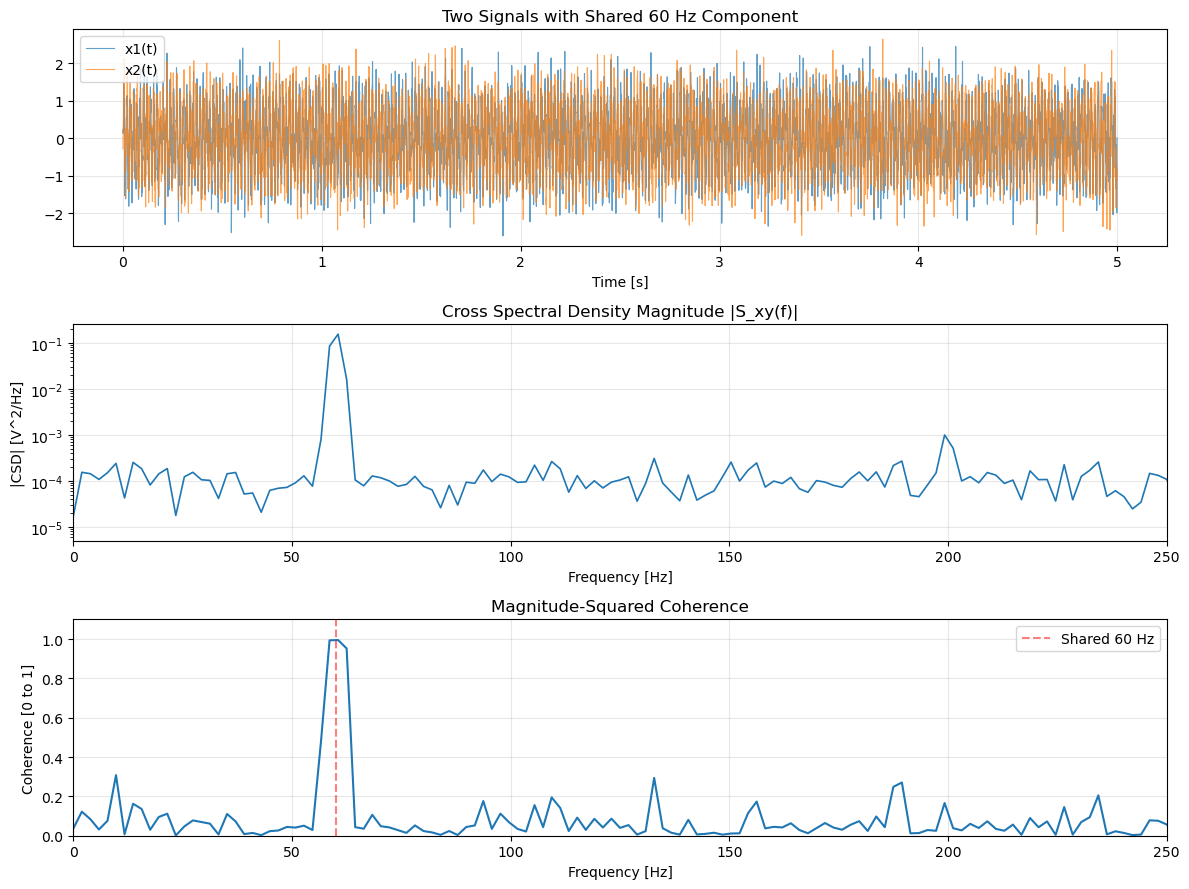

In [21]:
fs = 1000
t = np.arange(5000) / fs
common = np.sin(2 * np.pi * 60 * t)  # Shared 60 Hz component
noise1 = 0.5 * np.random.randn(len(t))
noise2 = 0.5 * np.random.randn(len(t))

# x1 has 60 Hz + 150 Hz + noise
x1 = common + noise1 + 0.3 * np.sin(2 * np.pi * 150 * t)
# x2 has 60 Hz + 200 Hz + noise (different interference)
x2 = common + noise2 + 0.3 * np.sin(2 * np.pi * 200 * t)

f_csd, Pxy = csd(x1, x2, fs=fs, nperseg=512)
f_coh, Cxy = coherence(x1, x2, fs=fs, nperseg=512)

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(t, x1, alpha=0.7, label='x1(t)', linewidth=0.8)
axes[0].plot(t, x2, alpha=0.7, label='x2(t)', linewidth=0.8)
axes[0].set_title('Two Signals with Shared 60 Hz Component')
axes[0].set_xlabel('Time [s]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(f_csd, np.abs(Pxy), linewidth=1.2)
axes[1].set_title('Cross Spectral Density Magnitude |S_xy(f)|')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('|CSD| [V^2/Hz]')
axes[1].set_xlim(0, 250)
axes[1].grid(True, alpha=0.3)

axes[2].plot(f_coh, Cxy, linewidth=1.5)
axes[2].axvline(60, color='r', linestyle='--', alpha=0.5, label='Shared 60 Hz')
axes[2].set_title('Magnitude-Squared Coherence')
axes[2].set_xlabel('Frequency [Hz]')
axes[2].set_ylabel('Coherence [0 to 1]')
axes[2].set_xlim(0, 250)
axes[2].set_ylim(0, 1.1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. PSD of Modulated Signals

Amplitude Modulation (AM) creates sidebands around a carrier frequency. For a carrier $f_c$ modulated by a tone at $f_m$:

$$x(t) = [1 + m \cos(2\pi f_m t)] \cos(2\pi f_c t)$$

The PSD shows a peak at the carrier $f_c$ and two sidebands at $f_c \pm f_m$, with power proportional to the modulation index $m$.


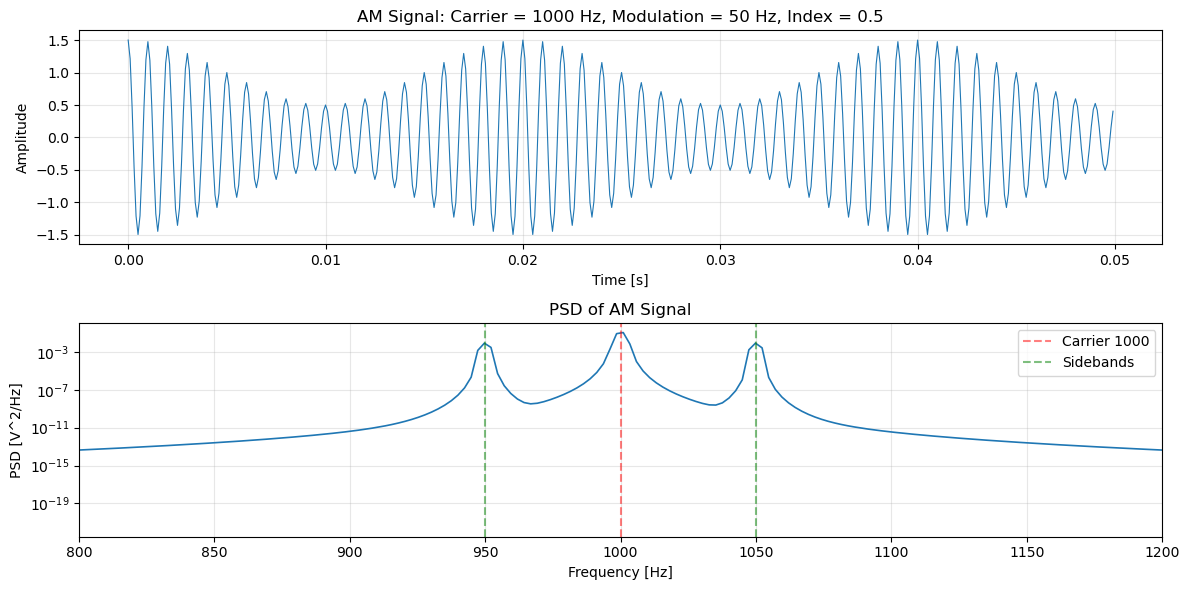

In [22]:
fs = 10000
t = np.arange(2 * fs) / fs
fc = 1000   # Carrier frequency
fm = 50     # Modulation frequency
m = 0.5     # Modulation index

am_signal = (1 + m * np.cos(2 * np.pi * fm * t)) * np.cos(2 * np.pi * fc * t)

f_am, psd_am = welch(am_signal, fs=fs, nperseg=4096)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:500], am_signal[:500], linewidth=0.8)
axes[0].set_title('AM Signal: Carrier = {} Hz, Modulation = {} Hz, Index = {}'.format(fc, fm, m))
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(f_am, psd_am, linewidth=1.2)
axes[1].axvline(fc, color='r', linestyle='--', alpha=0.5, label='Carrier {}'.format(fc))
axes[1].axvline(fc - fm, color='g', linestyle='--', alpha=0.5, label='Sidebands')
axes[1].axvline(fc + fm, color='g', linestyle='--', alpha=0.5)
axes[1].set_title('PSD of AM Signal')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('PSD [V^2/Hz]')
axes[1].set_xlim(800, 1200)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. dB Scaling and Dynamic Range

PSD is often expressed in decibels to handle large dynamic ranges:

$$S_{dB}(f) = 10 \log_{10}(S_{xx}(f))$$

This compresses the vertical scale and reveals weak spectral components that would be invisible on a linear plot. Normalizing to the peak (0 dB at maximum) is common for comparing spectral shapes.

Be careful: PSD in dB/Hz cannot be integrated directly; convert back to linear units first.


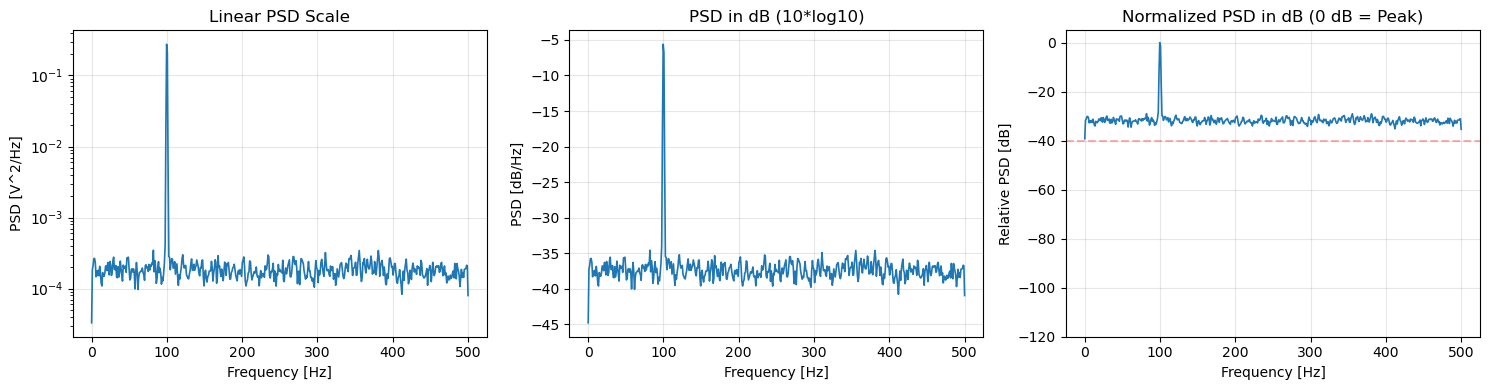

250 Hz tone in linear: 0.000186
250 Hz tone in dB:     -31.7 dB


In [23]:
fs = 1000
t = np.arange(10000) / fs
sig = (np.sin(2 * np.pi * 100 * t) + 
       0.01 * np.sin(2 * np.pi * 250 * t) + 
       0.3 * np.random.randn(len(t)))

f_psd, psd_lin = welch(sig, fs=fs, nperseg=1024)

psd_db = 10 * np.log10(psd_lin)
psd_db_norm = psd_db - np.max(psd_db)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(f_psd, psd_lin, linewidth=1.2)
axes[0].set_title('Linear PSD Scale')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('PSD [V^2/Hz]')
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_psd, psd_db, linewidth=1.2)
axes[1].set_title('PSD in dB (10*log10)')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('PSD [dB/Hz]')
axes[1].grid(True, alpha=0.3)

axes[2].plot(f_psd, psd_db_norm, linewidth=1.2)
axes[2].axhline(-40, color='r', linestyle='--', alpha=0.3)
axes[2].set_title('Normalized PSD in dB (0 dB = Peak)')
axes[2].set_xlabel('Frequency [Hz]')
axes[2].set_ylabel('Relative PSD [dB]')
axes[2].set_ylim(-120, 5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify we can see the weak 250 Hz tone in dB but not easily in linear
idx_250 = np.argmin(np.abs(f_psd - 250))
print("250 Hz tone in linear: {:.6f}".format(psd_lin[idx_250]))
print("250 Hz tone in dB:     {:.1f} dB".format(psd_db_norm[idx_250]))


## Summary

| Concept | Description |
|---------|-------------|
| **PSD Definition** | Power distribution over frequency, units V$^2$/Hz |
| **Periodogram** | Direct FFT-based estimate; high variance |
| **Welch's Method** | Averaged periodograms; lower variance, slightly worse resolution |
| **Windowing** | Controls leakage vs frequency resolution trade-off |
| **White Noise** | Flat PSD ($f^0$) |
| **Pink Noise** | PSD falls as $1/f$; equal power per octave |
| **Brown Noise** | PSD falls as $1/f^2$; strongly correlated low frequencies |
| **Parseval** | Integral of PSD equals mean squared signal amplitude |
| **CSD** | Complex cross-spectrum showing shared spectral power and phase |
| **Coherence** | Normalized CSD; 1 = perfect linear coupling at that frequency |
| **dB Scale** | Reveals weak components; use 10*log10 for power quantities |

Spectral density estimation is fundamental to understanding how signal power is distributed in frequency and how different signals relate to each other in the spectral domain.
